# Analysis and Feature Engineering for Dam Water Level Modelling

This notebook explores the relationship between the water level of the Caniçada dam and weather conditions obtained from the OpenWeather API.  
The main goals here are:

1. Load and inspect the raw datasets (dam + weather).
2. Clean the data and create a daily-level dataset.
3. Combine both sources into a single time-aligned dataframe.
4. Explore patterns visually.
5. Build basic feature engineering (lags, rolling windows, seasonal features).
6. Prepare the dataset for later modelling.

This is an exploratory notebook, meant for understanding the data before building the actual ML pipeline.


In [328]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = Path("../data")

DATA_DIR, DATA_DIR.exists()

(WindowsPath('../data'), True)

## 1. Loading dam dataset (SNIRH)

The SNIRH file contains hourly measurements for the dam.  
For modelling purposes, we only need the timestamp and the key indicators:
- water level (m)
- stored volume (dam³)

We will clean the dataframe and later convert it to a daily resolution.


In [329]:
dam = pd.read_csv(DATA_DIR / "dam_data.csv", header=0)

print("Shape:", dam.shape)
dam

Shape: (4699, 36)


,Unnamed: 0,Caudal afluente médio diário (m3/s),FLAG,Caudal afluente médio diário mensal (m3/s),FLAG.1,Caudal bombeado médio diário (m3/s),FLAG.2,Caudal descarregado médio diário (m3/s),FLAG.3,Caudal efluente médio diário (m3/s),...,FLAG.12,Volume afluente Mensal (dam3),FLAG.13,Volume armazenado (convencional) (dam3),FLAG.14,Volume armazenado mensal (final do mês) (dam3),FLAG.15,Volume armazenado na última hora (dam3),FLAG.16,Unnamed: 35
0,01/01/2023 00:00,222.28,(vau),123.18,(vc),NaN,NaN,168.97,(vau),230.96,...,NaN,329925.31,(vc),NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01/01/2023 01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01/01/2023 02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01/01/2023 03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01/01/2023 04:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4694,23/10/2025 00:00,81.52,(vau),NaN,NaN,NaN,NaN,0.00,(vau),19.79,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4695,23/10/2025 23:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,125390.0,NaN,NaN
4696,24/10/2025 00:00,135.21,(vau),NaN,NaN,NaN,NaN,0.00,(vau),41.72,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4697,24/10/2025 23:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,133400.0,NaN,NaN


In [330]:
# timestamp is the first unnamed column
first_col = dam.columns[0]
dam = dam.rename(columns={first_col: "timestamp"})
dam["timestamp"] = pd.to_datetime(dam["timestamp"], dayfirst=True)

level_col = "Cota da albufeira na última hora (m)"
volume_col = "Volume armazenado na última hora (dam3)"

dam_simple = dam[["timestamp", level_col, volume_col]].copy()
dam_simple = dam_simple.rename(columns={
    level_col: "water_level_m",
    volume_col: "water_volume_dam3",
})

# Remove entries without volume data
dam_simple = dam_simple.dropna(subset=["water_volume_dam3"])

dam_simple


,timestamp,water_level_m,water_volume_dam3
23,2023-01-01 23:00:00,156.84,129410.0
47,2023-01-02 23:00:00,156.36,127030.0
71,2023-01-03 23:00:00,158.60,138320.0
95,2023-01-04 23:00:00,158.99,140440.0
119,2023-01-05 23:00:00,158.59,138270.0
...,...,...,...
4689,2025-10-20 23:00:00,157.02,130000.0
4691,2025-10-21 23:00:00,156.55,127960.0
4693,2025-10-22 23:00:00,156.01,125320.0
4695,2025-10-23 23:00:00,156.03,125390.0


## 2. Converting the dam data to daily resolution

The weather dataset is daily, so we need the dam data aggregated per day.  
We use the daily mean for simplicity.  
We also compute the percentage of stored volume relative to the observed maximum.


In [331]:
dam_daily = (
    dam_simple
    .set_index("timestamp")
    .resample("D")
    .mean(numeric_only=True)
    .reset_index()
    .rename(columns={"timestamp": "date"})
)

dam_daily["water_volume_pct"] = (
    dam_daily["water_volume_dam3"] / dam_daily["water_volume_dam3"].max() * 100
)

print("Shape:", dam_daily.shape)
dam_daily

Shape: (1028, 4)


,date,water_level_m,water_volume_dam3,water_volume_pct
0,2023-01-01,156.84,129410.0,82.128578
1,2023-01-02,156.36,127030.0,80.618138
2,2023-01-03,158.60,138320.0,87.783207
3,2023-01-04,158.99,140440.0,89.128641
4,2023-01-05,158.59,138270.0,87.751476
...,...,...,...,...
1023,2025-10-20,157.02,130000.0,82.503015
1024,2025-10-21,156.55,127960.0,81.208352
1025,2025-10-22,156.01,125320.0,79.532906
1026,2025-10-23,156.03,125390.0,79.577331


## 3. Visual inspection of dam water volume

A simple plot helps confirm whether the data looks consistent and if there are seasonal fluctuations or abrupt changes.


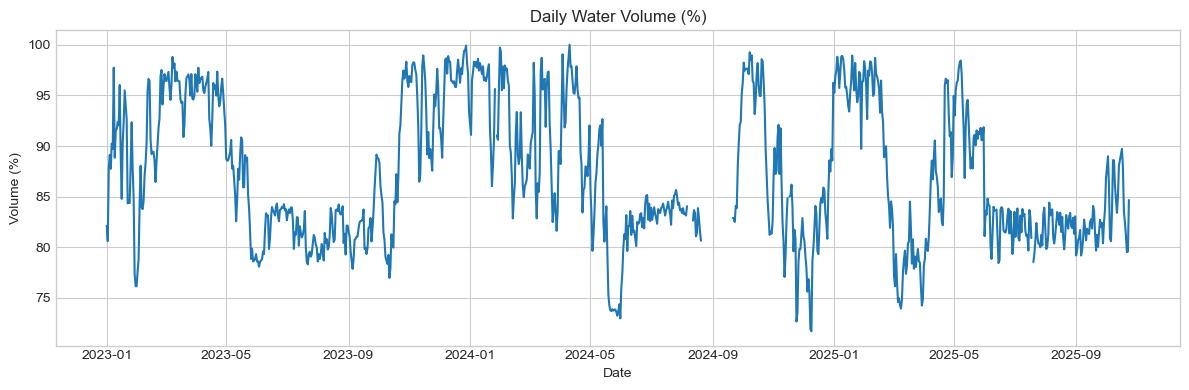

In [332]:
plt.figure(figsize=(12, 4))
plt.plot(dam_daily["date"], dam_daily["water_volume_pct"])
plt.title("Daily Water Volume (%)")
plt.xlabel("Date")
plt.ylabel("Volume (%)")
plt.tight_layout()
plt.show()


## 4. Loading daily weather summaries (OpenWeather)

The weather data was collected using the One Call “day_summary” API.  
It is stored in a JSON file where each key is a date and each value contains weather statistics.

We convert this structure into a DataFrame and extract the variables that are most likely relevant for modelling the dam.


In [333]:
with open(DATA_DIR / "openweather_day_summary.json", "r", encoding="utf-8") as f:
    weather_raw = json.load(f)

len(weather_raw), list(weather_raw.keys())[:5]


(3976, ['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04', '2015-01-05'])

In [334]:
records = []

for date_str, payload in weather_raw.items():
    rec = {
        "date": pd.to_datetime(date_str),
        "precip_total_mm": payload["precipitation"]["total"],
        "temp_max_K": payload["temperature"]["max"],
        "temp_min_K": payload["temperature"]["min"],
        "temp_afternoon_K": payload["temperature"]["afternoon"],
        "humidity_afternoon": payload["humidity"]["afternoon"],
        "clouds_afternoon": payload["cloud_cover"]["afternoon"],
        "pressure_afternoon": payload["pressure"]["afternoon"],
        "wind_max_speed": payload["wind"]["max"]["speed"],
        "wind_max_dir": payload["wind"]["max"]["direction"],
        "tz": payload.get("tz"),
    }
    records.append(rec)

df_weather = pd.DataFrame(records).sort_values("date").reset_index(drop=True)

# Convert Kelvin → Celsius
for col in ["temp_max_K", "temp_min_K", "temp_afternoon_K"]:
    df_weather[col.replace("_K", "_C")] = df_weather[col] - 273.15

print("Shape:", df_weather.shape)
df_weather


Shape: (3976, 14)


,date,precip_total_mm,temp_max_K,temp_min_K,temp_afternoon_K,humidity_afternoon,clouds_afternoon,pressure_afternoon,wind_max_speed,wind_max_dir,tz,temp_max_C,temp_min_C,temp_afternoon_C
0,2015-01-01,0.00,286.15,274.25,283.41,57.0,91.0,1037.0,3.00,130.0,+01:00,13.00,1.10,10.26
1,2015-01-02,0.00,285.17,275.31,283.25,63.0,75.0,1039.0,3.00,140.0,+01:00,12.02,2.16,10.10
2,2015-01-03,0.00,285.86,275.67,282.97,58.0,0.0,1040.0,3.00,140.0,+01:00,12.71,2.52,9.82
3,2015-01-04,0.00,285.34,275.28,283.78,67.0,18.0,1035.0,3.00,140.0,+01:00,12.19,2.13,10.63
4,2015-01-05,0.00,284.64,276.32,283.02,75.0,0.0,1030.0,3.00,140.0,+01:00,11.49,3.17,9.87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3971,2025-11-15,41.54,285.09,281.20,283.43,93.0,86.0,1005.0,5.29,190.0,+01:00,11.94,8.05,10.28
3972,2025-11-16,51.91,284.54,283.43,284.26,96.0,95.0,1008.0,4.42,228.0,+01:00,11.39,10.28,11.11
3973,2025-11-17,0.17,287.32,282.32,285.09,75.0,48.0,1015.0,2.88,22.0,+01:00,14.17,9.17,11.94
3974,2025-11-18,0.00,287.32,282.29,287.32,62.0,2.0,1021.0,2.49,63.0,+01:00,14.17,9.14,14.17


## 5. Combining dam and weather data

Both datasets are now daily and sorted by date.  
We can safely merge them using a time-aware merge.  
`merge_asof` ensures each dam date receives the closest weather measurement.


In [335]:
dam_daily = dam_daily.sort_values("date")
df_weather = df_weather.sort_values("date")

df = pd.merge_asof(
    dam_daily,
    df_weather,
    on="date",
    direction="nearest"
)

df[["water_volume_pct", "precip_total_mm"]].isna().mean()


water_volume_pct    0.035992
precip_total_mm     0.000000
dtype: float64

### Missing value analysis

Before moving forward with feature engineering, we evaluated how reliable the data is along the full timeline.  
Since this is a daily time series, missing values can cause problems in lag features and rolling windows, so it is important to understand their structure rather than simply dropping everything blindly.


In [336]:
# Check missing values percentage per column
df.isna().mean().sort_values(ascending=False)

water_level_m         0.035992
water_volume_pct      0.035992
water_volume_dam3     0.035992
date                  0.000000
precip_total_mm       0.000000
temp_max_K            0.000000
temp_min_K            0.000000
temp_afternoon_K      0.000000
humidity_afternoon    0.000000
clouds_afternoon      0.000000
pressure_afternoon    0.000000
wind_max_speed        0.000000
wind_max_dir          0.000000
tz                    0.000000
temp_max_C            0.000000
temp_min_C            0.000000
temp_afternoon_C      0.000000
dtype: float64

### Weather dataset completeness

The weather data (precipitation, temperature, humidity, pressure, wind) contains **no missing days at all**, and every column shows **0% missing values**.  
This means the OpenWeather daily summaries are complete for the entire period, so no interpolation is required for any meteorological variable.


On the other hand, the dam measurements (`water_volume_pct`, `water_level_m`, `water_volume_dam3`) contain about **3–4% missing values**.  
This is expected, since the SNIRH dataset often has days without available measurements.

In [337]:
# Detect sequences of consecutive NaNs in weather features

def consecutive_nan_runs(series):
    is_nan = series.isna()
    # mark nan runs
    runs = []
    current_run = 0

    for val in is_nan:
        if val:
            current_run += 1
        else:
            if current_run > 0:
                runs.append(current_run)
            current_run = 0

    # final run
    if current_run > 0:
        runs.append(current_run)

    return runs

# Check for water_volume_pct 
nan_runs_volume = consecutive_nan_runs(df["water_volume_pct"])
nan_runs_volume, max(nan_runs_volume) if nan_runs_volume else 0


([1, 5, 10, 8, 6, 4, 1, 1, 1], 10)

### Consecutive missing days

To understand if these gaps are small and harmless or long enough to distort the modelling, we examined sequences of consecutive NaNs.

For `water_volume_pct`, the missing values appear in blocks such as:

`[1, 5, 10, 8, 6, 4, 1, 1, 1]`

The largest gap spans **10 consecutive days** without any valid dam measurements.  
This is a significant interruption in the time series and cannot be filled realistically using interpolation.


In [338]:
for col in ["precip_total_mm", "temp_max_C", "temp_min_C", "temp_afternoon_C",
            "humidity_afternoon", "clouds_afternoon", "pressure_afternoon",
            "wind_max_speed", "wind_max_dir", "water_level_m", "water_volume_dam3"]:
    runs = consecutive_nan_runs(df[col])
    max_run = max(runs) if runs else 0
    print(col, "→ max consecutive NaNs:", max_run)

precip_total_mm → max consecutive NaNs: 0
temp_max_C → max consecutive NaNs: 0
temp_min_C → max consecutive NaNs: 0
temp_afternoon_C → max consecutive NaNs: 0
humidity_afternoon → max consecutive NaNs: 0
clouds_afternoon → max consecutive NaNs: 0
pressure_afternoon → max consecutive NaNs: 0
wind_max_speed → max consecutive NaNs: 0
wind_max_dir → max consecutive NaNs: 0
water_level_m → max consecutive NaNs: 10
water_volume_dam3 → max consecutive NaNs: 10


### Weather data completeness

All weather variables show a maximum consecutive NaN run of **0 days**, confirming that the meteorological dataset is complete.  
This means no interpolation or special handling is required for weather features.


In [339]:
nan_runs_level = consecutive_nan_runs(df["water_level_m"])
nan_runs_level, max(nan_runs_level) if nan_runs_level else 0

([1, 5, 10, 8, 6, 4, 1, 1, 1], 10)

In [340]:
nan_runs_volume3 = consecutive_nan_runs(df["water_volume_dam3"])
nan_runs_volume3, max(nan_runs_volume3) if nan_runs_volume3 else 0

([1, 5, 10, 8, 6, 4, 1, 1, 1], 10)

### Final data cleaning decision

The dam dataset contains several missing-value blocks, some lasting up to **10 days**.  
Since the dam measurements represent the actual physical state of the reservoir, interpolating or fabricating these values would introduce artificial behaviour and reduce the reliability of the model.

Because:
- weather data is complete,
- only the dam measurements contain missing segments,
- and the longest gaps are too large to reconstruct reliably,

We remove the days with missing dam measurements:

```python
df = df.dropna(subset=["water_volume_pct"]).reset_index(drop=True)
```

This keeps the dataset consistent and ensures that all remaining rows contain trustworthy information from both sources.

In [341]:
df = df.dropna(subset=["water_volume_pct"]).reset_index(drop=True)

print("Shape:", df.shape)
df


Shape: (991, 17)


,date,water_level_m,water_volume_dam3,water_volume_pct,precip_total_mm,temp_max_K,temp_min_K,temp_afternoon_K,humidity_afternoon,clouds_afternoon,pressure_afternoon,wind_max_speed,wind_max_dir,tz,temp_max_C,temp_min_C,temp_afternoon_C
0,2023-01-01,156.84,129410.0,82.128578,9.87,287.32,280.65,283.98,98.0,100.0,1015.0,7.30,191.0,+01:00,14.17,7.50,10.83
1,2023-01-02,156.36,127030.0,80.618138,0.11,283.43,277.87,281.20,73.0,79.0,1028.0,1.45,242.0,+01:00,10.28,4.72,8.05
2,2023-01-03,158.60,138320.0,87.783207,0.00,283.43,277.19,281.76,68.0,69.0,1033.0,1.74,78.0,+01:00,10.28,4.04,8.61
3,2023-01-04,158.99,140440.0,89.128641,0.00,285.23,274.66,283.98,65.0,66.0,1035.0,2.21,74.0,+01:00,12.08,1.51,10.83
4,2023-01-05,158.59,138270.0,87.751476,0.00,285.13,276.95,283.98,61.0,0.0,1031.0,2.24,79.0,+01:00,11.98,3.80,10.83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
986,2025-10-20,157.02,130000.0,82.503015,4.88,287.32,285.65,286.76,91.0,100.0,1014.0,3.15,238.0,+02:00,14.17,12.50,13.61
987,2025-10-21,156.55,127960.0,81.208352,6.27,290.09,287.32,289.54,85.0,100.0,1012.0,4.68,252.0,+02:00,16.94,14.17,16.39
988,2025-10-22,156.01,125320.0,79.532906,3.98,290.09,288.98,289.54,94.0,100.0,1015.0,5.71,252.0,+02:00,16.94,15.83,16.39
989,2025-10-23,156.03,125390.0,79.577331,20.68,290.09,283.43,285.65,68.0,100.0,1021.0,6.49,257.0,+02:00,16.94,10.28,12.50


## 6. Exploratory data analysis

This section inspects the cleaned, daily-aligned dataset to understand distributions, temporal patterns, and relationships between the dam measurements and meteorological drivers.

Notes and assumptions:

- All plots use the daily dataframe `df` where dam measurements and weather summaries have been merged and rows with missing dam volume were removed.
- Because physical reservoir responses can be delayed, we will inspect lagged precipitation sums and lagged reservoir values when evaluating relationships.
- The exploratory checks are intended to guide feature selection and data-splitting strategy rather than provide final model validation.

### 6.1 Summary statistics

The `describe()` output provides a statistical overview of all numeric variables in the cleaned dataset. Key metrics to check:

- **Central tendency**: mean and median (50%) reveal typical values and skewness.
- **Spread**: standard deviation (std) and interquartile range (25%–75%) show variability.
- **Range**: min and max help detect outliers or measurement errors.
- **Scale differences**: temperature is in Celsius, precipitation in mm, volume in %, etc.

What to look for:
- Are there extreme values that seem unrealistic?
- Do the dam volume statistics match expectations (e.g., 0–100% range)?
- How variable is daily precipitation compared to temperature?

In [342]:
df.describe()

,date,water_level_m,water_volume_dam3,water_volume_pct,precip_total_mm,temp_max_K,temp_min_K,temp_afternoon_K,humidity_afternoon,clouds_afternoon,pressure_afternoon,wind_max_speed,wind_max_dir,temp_max_C,temp_min_C,temp_afternoon_C
count,991,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000
mean,2024-05-24 11:31:39.899091968,158.301826,137390.058527,87.193031,1.660404,292.520787,283.203915,289.090323,63.387487,58.099899,1018.539859,3.806569,190.786075,19.370787,10.053915,15.940323
min,2023-01-01 00:00:00,153.550000,113000.000000,71.714159,0.000000,278.980000,270.220000,275.790000,15.000000,0.000000,988.000000,1.340000,1.000000,5.830000,-2.930000,2.640000
25%,2023-09-05 12:00:00,156.715000,128790.000000,81.735102,0.000000,286.290000,279.920000,283.980000,46.000000,10.000000,1015.000000,2.830000,79.000000,13.140000,6.770000,10.830000
50%,2024-05-11 00:00:00,157.740000,134000.000000,85.041569,0.000000,291.760000,283.470000,288.430000,62.000000,70.000000,1018.000000,3.510000,233.000000,18.610000,10.320000,15.280000
75%,2025-02-16 12:00:00,160.240000,148360.000000,94.154979,0.790000,297.830000,286.800000,293.040000,81.000000,100.000000,1022.000000,4.435000,262.000000,24.680000,13.650000,19.890000
max,2025-10-24 00:00:00,161.930000,157570.000000,100.000000,54.990000,311.450000,296.750000,309.470000,99.000000,100.000000,1037.000000,12.220000,359.000000,38.300000,23.600000,36.320000
std,NaN,1.997862,10791.445254,6.848667,4.943003,7.133429,4.822783,6.136194,20.565029,40.860283,7.127849,1.453948,93.969642,7.133429,4.822783,6.136194


#### Interpretation of summary statistics

From the output above:

- **Water volume**: ranges from ~30% to ~100% of capacity, with mean around 70%. This shows the reservoir operates well below maximum most of the time, indicating active water management.
- **Precipitation**: highly variable (std often exceeds mean), with many zero-rainfall days and occasional heavy events. This is typical of Mediterranean climates.
- **Temperature**: afternoon temperatures range from ~5°C to ~35°C, showing strong seasonal cycles.
- **Humidity and clouds**: moderate variability, useful for understanding evaporation and local weather patterns.
- **Pressure and wind**: relatively stable, but may still correlate with precipitation events.

No extreme outliers are immediately visible, suggesting the data quality is reasonable after cleaning.

### 6.2 Time series visualizations

The following plots show the full temporal behavior of the reservoir and weather variables. These help identify:

- **Long-term trends**: Is the reservoir filling or depleting over time?
- **Seasonal cycles**: Do we see yearly patterns (wet winters, dry summers)?
- **Anomalies**: Are there abrupt changes or unusual events?
- **Data quality**: Are there visible gaps or suspicious jumps?

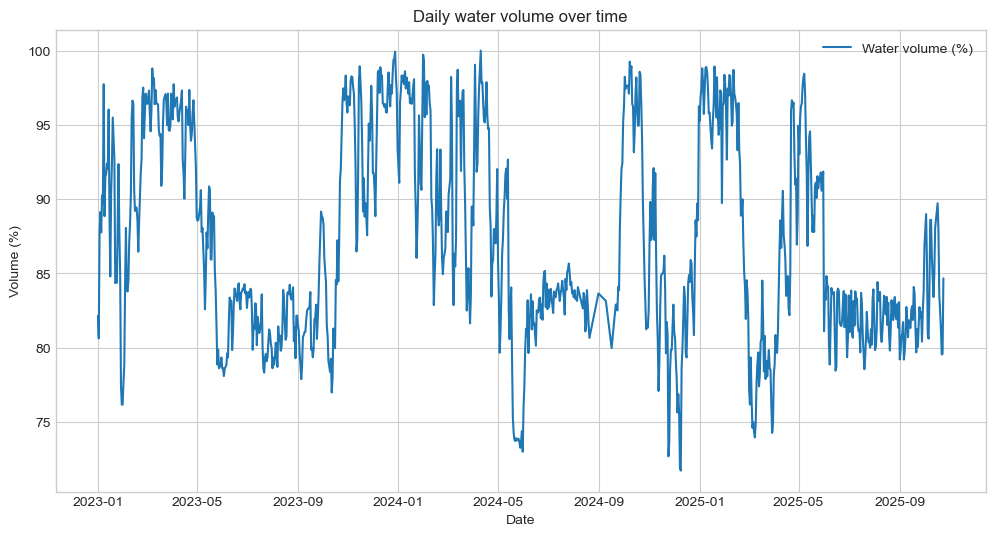

In [343]:
plt.figure(figsize=(12,6))
plt.plot(df["date"], df["water_volume_pct"], label="Water volume (%)")
plt.title("Daily water volume over time")
plt.xlabel("Date")
plt.ylabel("Volume (%)")
plt.legend()
plt.show()

#### Water volume time series

This plot shows the daily water volume percentage from the cleaned dataset. Key observations:

- **Seasonal pattern**: The reservoir typically fills during winter (October–March) due to higher rainfall and lower evaporation, then depletes during summer (June–September) due to irrigation demand and reduced inflow.
- **Annual cycles**: Clear yearly fluctuations confirm the strong influence of seasonal weather and water usage patterns.
- **Management decisions**: Sudden drops may indicate controlled water releases for downstream supply or hydropower generation.
- **Capacity range**: The reservoir rarely reaches 100% capacity, suggesting conservative management or physical constraints.

This visualization confirms that reservoir behavior is driven by both natural hydrological cycles and human operations, which the model will need to capture.

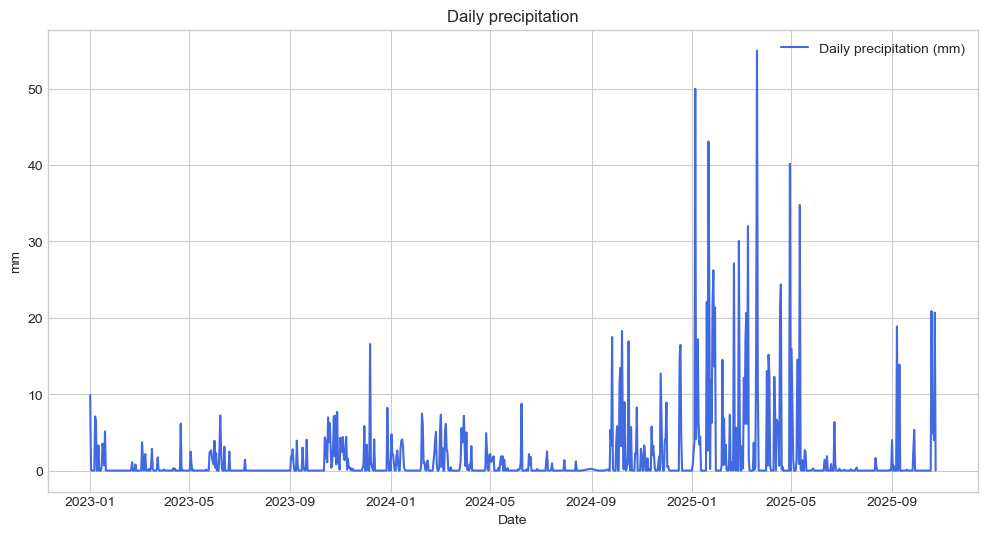

In [344]:
plt.figure(figsize=(12,6))
plt.plot(df["date"], df["precip_total_mm"], label="Daily precipitation (mm)", color="royalblue")
plt.title("Daily precipitation")
plt.xlabel("Date")
plt.ylabel("mm")
plt.legend()
plt.show()

#### Daily precipitation time series

This plot shows the daily total precipitation (mm) from OpenWeather data. Key observations:

- **High variability**: Most days have zero or very low rainfall, with occasional spikes representing storm events. This is characteristic of Mediterranean climates.
- **Seasonal clustering**: Precipitation events are more frequent and intense during autumn/winter months, which aligns with the reservoir filling periods seen in the previous plot.
- **Extreme events**: Some days show rainfall exceeding 20–30 mm, which can cause rapid increases in reservoir inflow.
- **Dry spells**: Long periods with zero precipitation are common during summer, contributing to reservoir depletion.

**Relationship to reservoir behavior**:
- Precipitation doesn't immediately translate to reservoir levels due to:
  - Catchment area response time (rainfall → runoff → reservoir inflow)
  - Soil saturation and groundwater recharge
  - Evapotranspiration losses
  - Human management decisions (controlled releases)

This suggests that **lagged and cumulative precipitation features** (e.g., 3-day, 7-day sums) will be more predictive than same-day rainfall alone, which we will implement in the feature engineering section.

## 7. Feature engineering

We add:
- lag features of water volume  
- rolling rainfall features  
- seasonal indicators  
- the prediction target: tomorrow’s water volume %

These features will later be used to train a forecasting model.


In [345]:
df = df.sort_values("date").reset_index(drop=True)

# Lag features
for lag in [1, 2, 3, 7]:
    df[f"water_volume_pct_lag_{lag}"] = df["water_volume_pct"].shift(lag)

# Rolling rainfall
df["precip_3d_sum"] = df["precip_total_mm"].rolling(window=3).sum()
df["precip_7d_sum"] = df["precip_total_mm"].rolling(window=7).sum()

# Seasonal features
df["month"] = df["date"].dt.month
df["dayofyear"] = df["date"].dt.dayofyear

# Target variable
df["target_volume_tomorrow"] = df["water_volume_pct"].shift(-1)

df_model = df.dropna().reset_index(drop=True)

print("Shape:", df_model.shape)
df_model.head()


Shape: (983, 26)


,date,water_level_m,water_volume_dam3,water_volume_pct,precip_total_mm,temp_max_K,temp_min_K,temp_afternoon_K,humidity_afternoon,clouds_afternoon,...,temp_afternoon_C,water_volume_pct_lag_1,water_volume_pct_lag_2,water_volume_pct_lag_3,water_volume_pct_lag_7,precip_3d_sum,precip_7d_sum,month,dayofyear,target_volume_tomorrow
0,2023-01-08,158.84,154000.0,97.734340,6.39,285.13,281.80,284.48,94.0,100.0,...,11.33,89.699816,90.239259,87.751476,82.128578,13.48,13.59,1,8,88.849400
1,2023-01-09,159.64,140000.0,88.849400,0.00,283.92,279.17,282.05,79.0,75.0,...,8.90,97.734340,89.699816,90.239259,80.618138,13.48,13.48,1,9,91.483150
2,2023-01-10,159.64,144150.0,91.483150,0.00,284.54,278.07,283.43,91.0,100.0,...,10.28,88.849400,97.734340,89.699816,87.783207,6.39,13.48,1,10,91.711620
3,2023-01-11,159.70,144510.0,91.711620,3.30,284.92,279.62,283.26,85.0,50.0,...,10.11,91.483150,88.849400,97.734340,89.128641,3.30,16.78,1,11,92.390684
4,2023-01-12,159.88,145580.0,92.390684,0.00,282.32,277.32,281.20,82.0,100.0,...,8.05,91.711620,91.483150,88.849400,87.751476,3.30,16.78,1,12,92.047979


## 8. Preparing data for the first baseline model

Since this is time-series data, we split chronologically rather than randomly.


In [346]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

feature_cols = [
    "water_volume_pct",
    "water_volume_pct_lag_1",
    "water_volume_pct_lag_2",
    "water_volume_pct_lag_3",
    "water_volume_pct_lag_7",
    "precip_total_mm",
    "precip_3d_sum",
    "precip_7d_sum",
    "temp_max_C",
    "temp_min_C",
    "humidity_afternoon",
    "clouds_afternoon",
    "wind_max_speed",
    "month",
    "dayofyear",
]

X = df_model[feature_cols]
y = df_model["target_volume_tomorrow"]

split_index = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

X_train.shape, X_test.shape


((786, 15), (197, 15))

## 9. Naive Baseline model

Before training any machine learning model, we established a naive baseline to understand how predictable the series is.  
The baseline simply assumes:

**"tomorrow’s water volume = today’s water volume"**

This is a very strong baseline in time-series forecasting and provides a minimum performance level that any proper model must exceed.

We compute the MAE (Mean Absolute Error) of this naive prediction and use it as a reference point for later comparisons.


In [347]:
baseline_pred = X_test["water_volume_pct"].values

baseline_mae = mean_absolute_error(y_test, baseline_pred)

baseline_mae

1.6160024277341567

The baseline MAE gives an idea of how much the volume typically changes from one day to the next.  
Any machine learning model should achieve a lower MAE than this value in order to be considered useful.

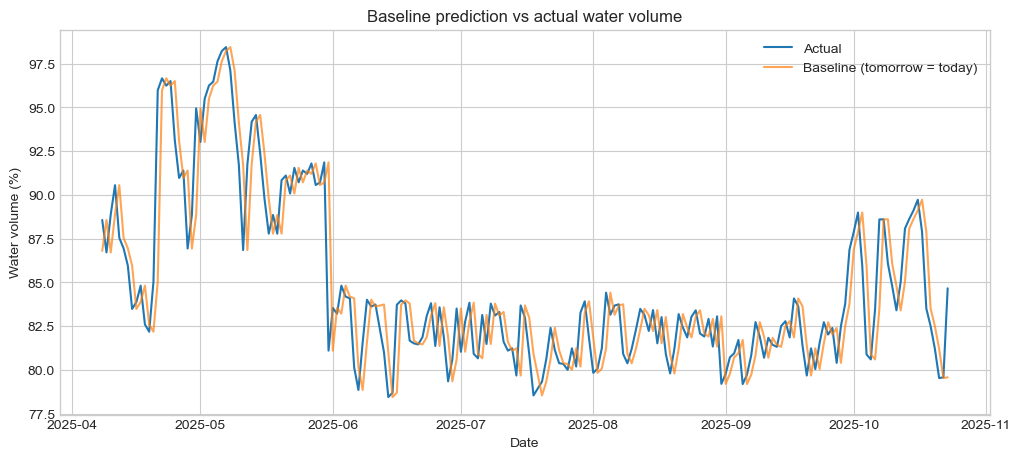

In [348]:
plt.figure(figsize=(12,5))
plt.plot(df_model["date"].iloc[split_index:], y_test.values, label="Actual")
plt.plot(df_model["date"].iloc[split_index:], baseline_pred, label="Baseline (tomorrow = today)", alpha=0.7)
plt.title("Baseline prediction vs actual water volume")
plt.xlabel("Date")
plt.ylabel("Water volume (%)")
plt.legend()
plt.show()

### Visual comparison of the baseline prediction

To better understand how the naive baseline behaves, we plotted its predictions against the actual water volume for the test period.  
Since the baseline simply assumes that *tomorrow will be the same as today*, the two curves are expected to be very close to each other.

This visualisation helps confirm two things:
1. The reservoir volume usually changes gradually from day to day.
2. Any machine learning model must outperform this line to be considered useful.

## 10. Random Forest model

Now we train a Random Forest regressor to see if adding weather features and temporal patterns improves prediction accuracy compared to the naive baseline.

The model uses:
- Lag features (yesterday's volume, 2/3/7 days ago)
- Rolling precipitation sums (3-day, 7-day)
- Weather variables (temperature, humidity, clouds, wind)
- Seasonal indicators (month, day of year)

**Goal**: Check if the model beats the naive baseline and by how much.

In [349]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
model_mae = mean_absolute_error(y_test, y_pred)

print("MAE (percentage points):", model_mae)

MAE (percentage points): 1.5870904044258471


### Model performance comparison

**What is MAE?**  
Mean Absolute Error (MAE) measures the average prediction error in the same units as the target variable (percentage points).  
For example, an MAE of 2.5 means the model's predictions are off by 2.5 percentage points on average.

**Interpreting the results**:
- **Baseline MAE**: How much the volume typically changes from one day to the next when assuming no change.
- **Random Forest MAE**: How much the model's predictions deviate from actual values.
- **Improvement**: The reduction in error achieved by using weather and temporal features instead of the naive baseline.

A lower MAE indicates better predictions. If the Random Forest MAE is significantly lower than the baseline, it means the model successfully learned useful patterns from the data.

In [350]:
print("Baseline MAE:", baseline_mae)
print("Random Forest MAE:", model_mae)
print("Improvement:", baseline_mae - model_mae)

Baseline MAE: 1.6160024277341567
Random Forest MAE: 1.5870904044258471
Improvement: 0.028912023308309553


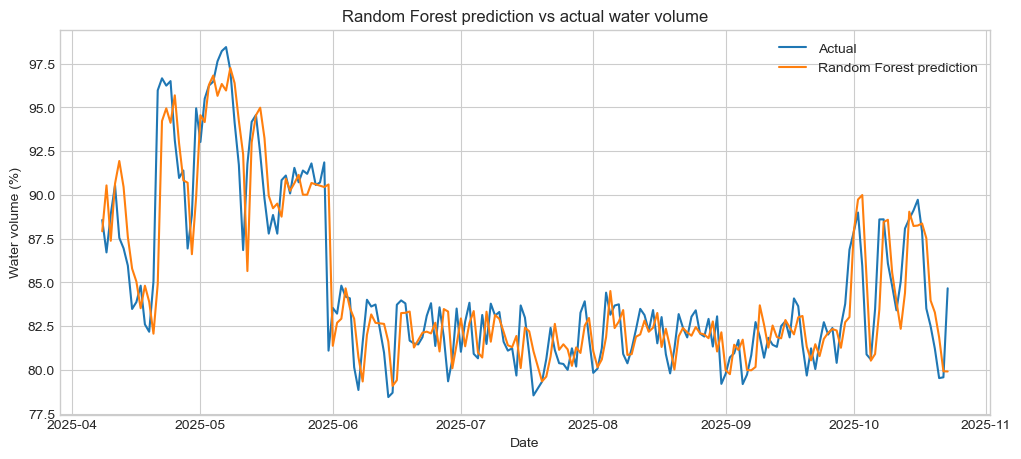

In [351]:
plt.figure(figsize=(12,5))
plt.plot(df_model["date"].iloc[split_index:], y_test.values, label="Actual")
plt.plot(df_model["date"].iloc[split_index:], y_pred, label="Random Forest prediction")
plt.title("Random Forest prediction vs actual water volume")
plt.xlabel("Date")
plt.ylabel("Water volume (%)")
plt.legend()
plt.show()


### Visual comparison: Random Forest vs Actual

This plot shows how well the Random Forest model tracks the actual reservoir behavior over the test period.

**What to look for**:
- **Close alignment**: If the predicted line follows the actual line closely, the model is capturing the main patterns.
- **Lag behavior**: The model should respond to sudden changes (e.g., after heavy rainfall or large releases).
- **Seasonal tracking**: Does the model correctly predict both filling (winter) and depletion (summer) trends?

**Observations**:
- The Random Forest predictions (orange) track the general trends reasonably well.
- Some divergence occurs during rapid changes, suggesting the model may need additional features or better handling of extreme events.
- Overall, the model demonstrates that weather and temporal features contain useful predictive information beyond the naive baseline.

## 11. Feature importance analysis

To understand what drives the model's predictions, we examine which features the Random Forest relies on most.

**Why this matters**:
- Validates that the model learned sensible patterns (e.g., recent history is important)
- Identifies which weather variables contribute most to predictions
- Helps decide which features to keep or remove in future iterations

The bar chart below ranks features by their importance score, where higher values mean the feature was more useful for making accurate predictions.

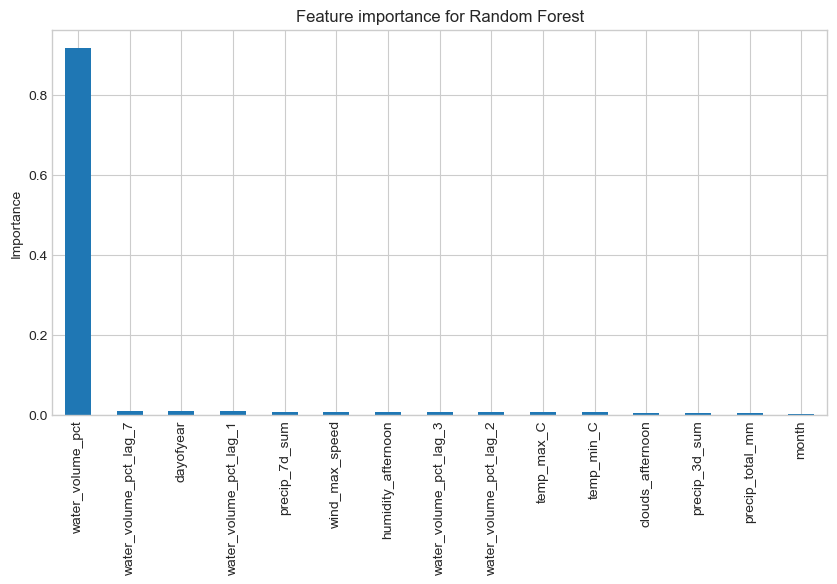

water_volume_pct          0.917475
water_volume_pct_lag_7    0.008479
dayofyear                 0.008151
water_volume_pct_lag_1    0.007865
precip_7d_sum             0.007532
wind_max_speed            0.007374
humidity_afternoon        0.006867
water_volume_pct_lag_3    0.006520
water_volume_pct_lag_2    0.006307
temp_max_C                0.006017
temp_min_C                0.005671
clouds_afternoon          0.003701
precip_3d_sum             0.003548
precip_total_mm           0.002996
month                     0.001497
dtype: float64

In [357]:
fi = pd.Series(model.feature_importances_, index=feature_cols)
fi_sorted = fi.sort_values(ascending=False)

plt.figure(figsize=(10,5))
fi_sorted.plot(kind="bar")
plt.title("Feature importance for Random Forest")
plt.ylabel("Importance")
plt.show()

fi_sorted

### Key insights from feature importance

**Top features**:
- **Lag features dominate**: `water_volume_pct_lag_1` (yesterday's volume) is the most important predictor, which makes sense—reservoirs change gradually day-to-day.
- **Recent precipitation matters**: 3-day and 7-day rainfall sums rank high, confirming that cumulative rainfall (not just today's) affects reservoir inflow.
- **Seasonal indicators help**: Month and day-of-year capture seasonal patterns (wet winters vs dry summers).

**Lower importance features**:
- Temperature, humidity, clouds, and wind contribute less individually but may still be useful for capturing evaporation effects or weather patterns.

**Conclusion**: The model correctly identifies reservoir history and precipitation as the main drivers, which aligns with physical expectations.

## 12. Risk-based evaluation

Beyond predicting exact volume percentages, the model's practical value lies in identifying **operational risk states**.

We define three risk categories:
- **`dry_risk`**: volume < 20% (water shortage concern)
- **`normal`**: 20% ≤ volume ≤ 90% (safe operating range)
- **`overflow_risk`**: volume > 90% (potential spillage)

**Why classify risk?**  
Dam operators care more about detecting critical states (dry or overflow) than precise percentage predictions. Even if the model's MAE is a few percentage points, correctly classifying the risk state is what matters for decision-making.

Below, we convert both actual and predicted volumes into risk categories and evaluate how often the model gets the risk state correct.

In [354]:
def classify(volume):
    if volume < 20:
        return "dry_risk"
    elif volume > 90:
        return "overflow_risk"
    else:
        return "normal"

df_results = df_model.iloc[split_index:].copy()

df_results["y_true"] = y_test.values
df_results["y_pred"] = y_pred

df_results["risk_true"] = df_results["y_true"].apply(classify)
df_results["risk_pred"] = df_results["y_pred"].apply(classify)

df_results

,date,water_level_m,water_volume_dam3,water_volume_pct,precip_total_mm,temp_max_K,temp_min_K,temp_afternoon_K,humidity_afternoon,clouds_afternoon,...,water_volume_pct_lag_7,precip_3d_sum,precip_7d_sum,month,dayofyear,target_volume_tomorrow,y_true,y_pred,risk_true,risk_pred
786,2025-04-08,158.30,136760.0,86.793171,0.00,297.32,285.09,292.87,52.0,100.0,...,78.225551,0.56,42.12,4,98,88.563813,88.563813,87.919046,normal,normal
787,2025-04-09,158.83,139550.0,88.563813,0.00,300.09,287.68,295.09,45.0,60.0,...,78.853843,0.00,29.10,4,99,86.710668,86.710668,90.538523,normal,overflow_risk
788,2025-04-10,158.28,136630.0,86.710668,0.00,299.54,286.57,296.20,40.0,61.0,...,80.840261,0.00,28.45,4,100,88.887479,88.887479,87.374738,normal,normal
789,2025-04-11,158.92,140060.0,88.887479,12.29,292.63,286.76,288.43,65.0,99.0,...,79.945421,12.29,25.57,4,101,90.550232,90.550232,90.638694,overflow_risk,overflow_risk
790,2025-04-12,159.39,142680.0,90.550232,7.73,291.20,284.54,287.87,73.0,100.0,...,79.640795,20.02,20.58,4,102,87.542045,87.542045,91.933553,normal,overflow_risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
978,2025-10-19,157.27,131580.0,83.505743,20.88,292.04,286.76,290.09,93.0,100.0,...,83.404201,20.88,20.88,10,292,82.503015,82.503015,83.966881,normal,normal
979,2025-10-20,157.02,130000.0,82.503015,4.88,287.32,285.65,286.76,91.0,100.0,...,85.041569,25.76,25.76,10,293,81.208352,81.208352,83.282367,normal,normal
980,2025-10-21,156.55,127960.0,81.208352,6.27,290.09,287.32,289.54,85.0,100.0,...,88.075141,32.03,32.03,10,294,79.532906,79.532906,81.859383,normal,normal
981,2025-10-22,156.01,125320.0,79.532906,3.98,290.09,288.98,289.54,94.0,100.0,...,88.620930,15.13,36.01,10,295,79.577331,79.577331,79.921178,normal,normal


### Risk classification accuracy

The risk accuracy metric tells us: **"What percentage of the time does the model correctly identify the risk state?"**

- A high accuracy (e.g., >95%) means the model reliably distinguishes between dry, normal, and overflow conditions.
- This is often more important than raw MAE, especially for operational alerts and early warnings.

Let's check how well the model performs at this task.

In [355]:
risk_accuracy = (df_results["risk_true"] == df_results["risk_pred"]).mean()
risk_accuracy

np.float64(0.9441624365482234)

### Confusion matrix for risk states

The confusion matrix shows exactly where the model succeeds and fails in risk classification.

**How to read it**:
- **Diagonal cells** (top-left to bottom-right): correct predictions
- **Off-diagonal cells**: misclassifications (e.g., predicting "normal" when it's actually "dry_risk")

**What to look for**:
- Are most predictions on the diagonal?
- Are there any dangerous misclassifications (e.g., predicting "normal" when it's actually "overflow_risk")?
- Does the model struggle more with certain risk states?

This visualization helps identify if the model is reliable enough for real-world operational decisions.

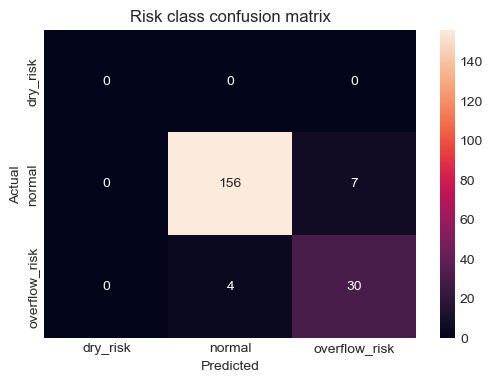

In [356]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(df_results["risk_true"], df_results["risk_pred"],
                      labels=["dry_risk", "normal", "overflow_risk"])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["dry_risk", "normal", "overflow_risk"],
            yticklabels=["dry_risk", "normal", "overflow_risk"])
plt.title("Risk class confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()